In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Annotated, TypedDict, Literal
import operator
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv(override= True)

c:\Users\pumas\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [2]:
class State(TypedDict):
    topic:str
    tweet:str
    evaluation: Literal["approved","need_optimization"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]


In [3]:
class evaluation_schema(BaseModel):
    evaluation: Literal["approved","need_optimization"] = Field(description="Evaluation of the given tweet. Return either approved or need_optimization.")
    feedback: str = Field(description="Feedback of the tweet given.")

In [4]:
generator_model = ChatGroq(model = "openai/gpt-oss-20b")
evaluator_model = ChatGroq(model = "openai/gpt-oss-20b")
optimzer_model = ChatGroq(model = "openai/gpt-oss-20b")

evaluator_model_with_schema = evaluator_model.with_structured_output(evaluation_schema)

In [5]:
def generate_tweet(old_State: State) -> State:
    prompt = [
        SystemMessage(
            content="""You are a professional X (Twitter) copywriter. Turn ideas into sharp, original, high-engagement tweets. Write like a smart human, not an AI. Use a strong hook, clear wording, and natural personality. Avoid clichés, generic motivational language, unnecessary hashtags, and emojis. Never explain your answer. Output only the final tweet."""
        ),
        HumanMessage(
            content=f"""Write one tweet about:

{old_State['topic']}

Requirements:
- Not less than 250 characters
- Not more than 500 characters
- Start with a strong hook
- Make it useful, interesting, or thought-provoking
- Keep it concise and natural
- Use simple, punchy language
- No hashtags unless truly relevant
- No quotation marks
- Output only the tweet"""
        )
    ]

    response = generator_model.invoke(prompt)

    return {
        "tweet": response.content,
        "tweet_history": [response.content]
    }


def evaluate_tweet(old_State: State) -> State:
    prompt = [
        SystemMessage(
            content="""You are an expert X (Twitter) content editor.

Evaluate the generated tweet for:
- Relevance to the topic
- Strong and clear hook
- Engagement potential
- Originality
- Natural human-like writing
- Clarity and conciseness
- Correctness
- Not less than 250 characters
- Not more than 500 characters

Approve the tweet only if it is strong enough to publish as-is.

If it needs improvement, provide specific, actionable feedback explaining what should be changed.

Do not rewrite the tweet. Only evaluate it."""
        ),
        HumanMessage(
            content=f"""Evaluate this tweet:

Topic:
{old_State['topic']}

Tweet:
{old_State['tweet']}

Decide whether the tweet is "approved" or "need_optimization".

If approved, give a brief reason.
If optimization is needed, explain the specific problems and how to improve them."""
        )
    ]

    response = evaluator_model_with_schema.invoke(prompt)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "feedback_history":[response.feedback]
    }


def optimize_tweet(old_State: State) -> State:
    prompt = [
        SystemMessage(
            content="""You are an expert X (Twitter) copywriter.

Improve the given tweet based on the evaluator's feedback.

Keep the original topic and core idea, but fix the identified problems. Make the tweet sharp, natural, engaging, and human-like.

Requirements:
- Not less than 250 characters
- Not more than 500 characters
- Strong hook
- Clear and concise
- Useful, interesting, or thought-provoking
- Simple, punchy language
- Avoid clichés and generic wording
- No unnecessary hashtags or emojis
- No quotation marks
- Output only the improved tweet."""
        ),
        HumanMessage(
            content=f"""Optimize this tweet:

Topic:
{old_State['topic']}

Current tweet:
{old_State['tweet']}

Evaluator feedback:
{old_State['feedback']}

Return only the improved tweet."""
        )
    ]

    response = optimzer_model.invoke(prompt)

    new_iteration = old_State["iteration"] + 1
    
    return {
        "tweet": response.content,
        "tweet_history": [response.content],
        "iteration":new_iteration
    }


def eval_router(old_State: State) -> State:
    if old_State['evaluation'] == "approved" or old_State["iteration"] >= old_State['max_iteration']:
        return "approved"
    else:
        return "need optimization"

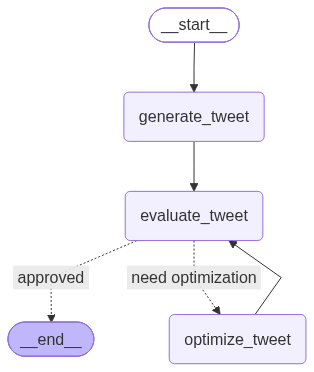

In [6]:
graph = StateGraph(State)
graph.add_node("generate_tweet",generate_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("optimize_tweet",optimize_tweet)

graph.add_edge(START,"generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet",eval_router,{"approved": END,"need optimization":"optimize_tweet"})
graph.add_edge("optimize_tweet","evaluate_tweet")

workflow = graph.compile()
workflow

In [8]:
initial_data = {"topic":"Trains in India",'iteration':1,"max_iteration":5}
response = workflow.invoke(initial_data)
response

{'topic': 'Trains in India',
 'tweet': 'Ever wonder how a single train can carry the heartbeat of a nation? In India, 13,000 trains move 5\u202fmillion passengers daily over 68,000\u202fkm of track, making rail the world’s busiest lifeline. From cramped sleeper cars to high‑speed Vande\u202fBharat Express, the network is a living, breathing economy that keeps the country moving.',
 'evaluation': 'approved',
 'feedback': 'The tweet is engaging, well‑structured, and within the character limits. It hooks readers with a vivid question, delivers impressive stats, and showcases India’s rail network with vivid imagery. No revisions needed.',
 'iteration': 2,
 'max_iteration': 5,
 'tweet_history': ["Ever wonder how a single train can carry the heartbeat of a nation? In India, 13,000 trains daily ferry 5 million passengers across 68,000 km of track, turning railways into the world's busiest lifeline. From cramped sleeper cars to high‑speed bullet trains, the rail network is a living, breathing 